# 06 — Factory Location Strategy
Weighted scoring model to identify optimal districts for a new eco-brick factory.
Criteria: demand, competition, raw material access, eco adoption gap, market stability.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

district = pd.read_csv('../data/processed/brick_gap_analysis.csv')
print(district.shape)
district.head()

(31, 21)


,Districts,factory_count,running_count,eco_count,fully_auto_count,closure_count,operational_rate,eco_share,closure_rate,population_2011,...,modern_per_100k,pop_norm,modern_norm,gap_score,households_2011_x,factories_per_1000_hh,modern_per_1000_hh,households_2011_y,households_2011,gap_score_hh
0,Adilabad,3,2,3,0,1,66.7,100.0,33.3,708972,...,0.00,0.070285,0.000000,0.070,170234,0.018,0.000,170234,170234,0.067
1,Bhadradri Kothagudem,10,9,9,0,1,90.0,90.0,10.0,1068457,...,0.00,0.143140,0.000000,0.143,261445,0.038,0.000,261445,261445,0.140
2,Hanumakonda,22,19,19,2,3,86.4,86.4,13.6,793418,...,0.25,0.087399,0.416667,0.051,196876,0.112,0.010,196876,196876,0.053
3,Hyderabad,30,28,26,13,2,93.3,86.7,6.7,3943323,...,0.33,0.725778,0.550000,0.327,1005646,0.030,0.013,1005646,1005646,0.351
4,Jagtial,10,8,6,0,2,80.0,60.0,20.0,983414,...,0.00,0.125905,0.000000,0.126,238891,0.042,0.000,238891,238891,0.122


In [3]:
# ── CRITERION 1: Demand (household count) ──────────────────
# More households = more potential buyers
district['score_demand'] = (
    (district['households_2011'] - district['households_2011'].min()) /
    (district['households_2011'].max() - district['households_2011'].min())
).round(3)

# ── CRITERION 2: Competition (inverted factory density) ─────
# Fewer factories per household = less competition = better
district['score_competition'] = (
    1 - (district['factories_per_1000_hh'] - district['factories_per_1000_hh'].min()) /
    (district['factories_per_1000_hh'].max() - district['factories_per_1000_hh'].min())
).round(3)

# ── CRITERION 3: Modernization gap (inverted modern density) 
# Fewer fully automatic competitors = bigger opportunity
district['score_modern_gap'] = (
    1 - (district['modern_per_1000_hh'] - district['modern_per_1000_hh'].min()) /
    (district['modern_per_1000_hh'].max() - district['modern_per_1000_hh'].min())
).round(3)

# ── CRITERION 4: Eco adoption gap ───────────────────────────
# Low eco share = customers ready to switch = opportunity
district['score_eco_gap'] = (
    1 - (district['eco_share'] - district['eco_share'].min()) /
    (district['eco_share'].max() - district['eco_share'].min())
).round(3)

# ── CRITERION 5: Market stability ───────────────────────────
# Low closure rate = stable demand
district['score_stability'] = (
    1 - (district['closure_rate'] - district['closure_rate'].min()) /
    (district['closure_rate'].max() - district['closure_rate'].min())
).round(3)

# ── RAW MATERIAL BONUS: Peddapalli adjacency to Ramagundam ──
# Manual bonus for districts near NTPC Ramagundam fly ash source
ramagundam_districts = ['Peddapalli', 'Karimnagar', 'Jagtial', 'Mancherial']
district['score_raw_material'] = district['Districts'].apply(
    lambda x: 1.0 if x in ramagundam_districts else 0.3
)

print("Criteria computed ✓")
district[['Districts', 'score_demand', 'score_competition', 
          'score_modern_gap', 'score_eco_gap', 
          'score_stability', 'score_raw_material']].head(10)

Criteria computed ✓


,Districts,score_demand,score_competition,score_modern_gap,score_eco_gap,score_stability,score_raw_material
0,Adilabad,0.067,0.909,1.00,0.000,0.445,0.3
1,Bhadradri Kothagudem,0.140,0.779,1.00,0.100,0.833,0.3
2,Hanumakonda,0.088,0.299,0.60,0.136,0.773,0.3
3,Hyderabad,0.732,0.831,0.48,0.133,0.888,0.3
4,Jagtial,0.122,0.753,1.00,0.400,0.667,1.0
5,Jangaon,0.052,0.422,0.72,0.214,0.882,0.3
6,Jayashankar Bhupalpally,0.045,0.708,0.72,0.143,0.285,0.3
7,Jogulamba Gadwal,0.053,0.773,0.48,0.333,0.445,0.3
8,Kamareddy,0.118,1.000,1.00,1.000,1.000,0.3
9,Karimnagar,0.146,0.545,0.56,0.500,1.000,1.0


In [4]:
# ── WEIGHTS (must sum to 1.0) ────────────────────────────────
# Justify every weight — this is your analytical argument
weights = {
    'demand':        0.25,  # household count — market size matters most
    'competition':   0.20,  # fewer competitors = better entry conditions
    'modern_gap':    0.20,  # modernization gap = direct opportunity
    'eco_gap':       0.15,  # eco adoption gap = product-market fit
    'stability':     0.10,  # stable market reduces risk
    'raw_material':  0.10,  # fly ash access = cost advantage
}
# Total: 1.00

district['composite_score'] = (
    district['score_demand']       * weights['demand'] +
    district['score_competition']  * weights['competition'] +
    district['score_modern_gap']   * weights['modern_gap'] +
    district['score_eco_gap']      * weights['eco_gap'] +
    district['score_stability']    * weights['stability'] +
    district['score_raw_material'] * weights['raw_material']
).round(3)

# Final ranking
ranked = district.nlargest(31, 'composite_score')[
    ['Districts', 'composite_score', 'score_demand', 
     'score_competition', 'score_modern_gap', 
     'score_eco_gap', 'score_stability', 'score_raw_material']
]
print("=== FULL DISTRICT RANKING ===")
print(ranked.to_string(index=False))

=== FULL DISTRICT RANKING ===
              Districts  composite_score  score_demand  score_competition  score_modern_gap  score_eco_gap  score_stability  score_raw_material
            Ranga Reddy            0.797         1.000              1.000              0.96          0.167            1.000                 0.3
              Kamareddy            0.710         0.118              1.000              1.00          1.000            1.000                 0.3
             Wanaparthy            0.687         0.044              0.981              1.00          1.000            1.000                 0.3
             Sangareddy            0.611         0.185              0.799              0.76          0.818            1.000                 0.3
                Jagtial            0.608         0.122              0.753              1.00          0.400            0.667                 1.0
              Nizamabad            0.602         0.226              0.974              0.88          0.667

In [5]:
# Does the top 3 change if we shift weights ±10%?
scenarios = {
    'Base':         {'demand':0.25,'competition':0.20,'modern_gap':0.20,
                     'eco_gap':0.15,'stability':0.10,'raw_material':0.10},
    'Demand heavy': {'demand':0.35,'competition':0.15,'modern_gap':0.15,
                     'eco_gap':0.15,'stability':0.10,'raw_material':0.10},
    'Competition heavy': {'demand':0.20,'competition':0.30,'modern_gap':0.20,
                          'eco_gap':0.15,'stability':0.05,'raw_material':0.10},
    'Raw material heavy': {'demand':0.20,'competition':0.20,'modern_gap':0.20,
                           'eco_gap':0.10,'stability':0.10,'raw_material':0.20},
}

print("=== SENSITIVITY CHECK — Top 3 by scenario ===\n")
for scenario, w in scenarios.items():
    district['temp_score'] = (
        district['score_demand']      * w['demand'] +
        district['score_competition'] * w['competition'] +
        district['score_modern_gap']  * w['modern_gap'] +
        district['score_eco_gap']     * w['eco_gap'] +
        district['score_stability']   * w['stability'] +
        district['score_raw_material']* w['raw_material']
    )
    top3 = district.nlargest(3, 'temp_score')['Districts'].tolist()
    print(f"{scenario:25s}: {top3}")

=== SENSITIVITY CHECK — Top 3 by scenario ===

Base                     : ['Ranga Reddy', 'Kamareddy', 'Wanaparthy']
Demand heavy             : ['Ranga Reddy', 'Kamareddy', 'Wanaparthy']
Competition heavy        : ['Ranga Reddy', 'Kamareddy', 'Wanaparthy']
Raw material heavy       : ['Ranga Reddy', 'Kamareddy', 'Jagtial']


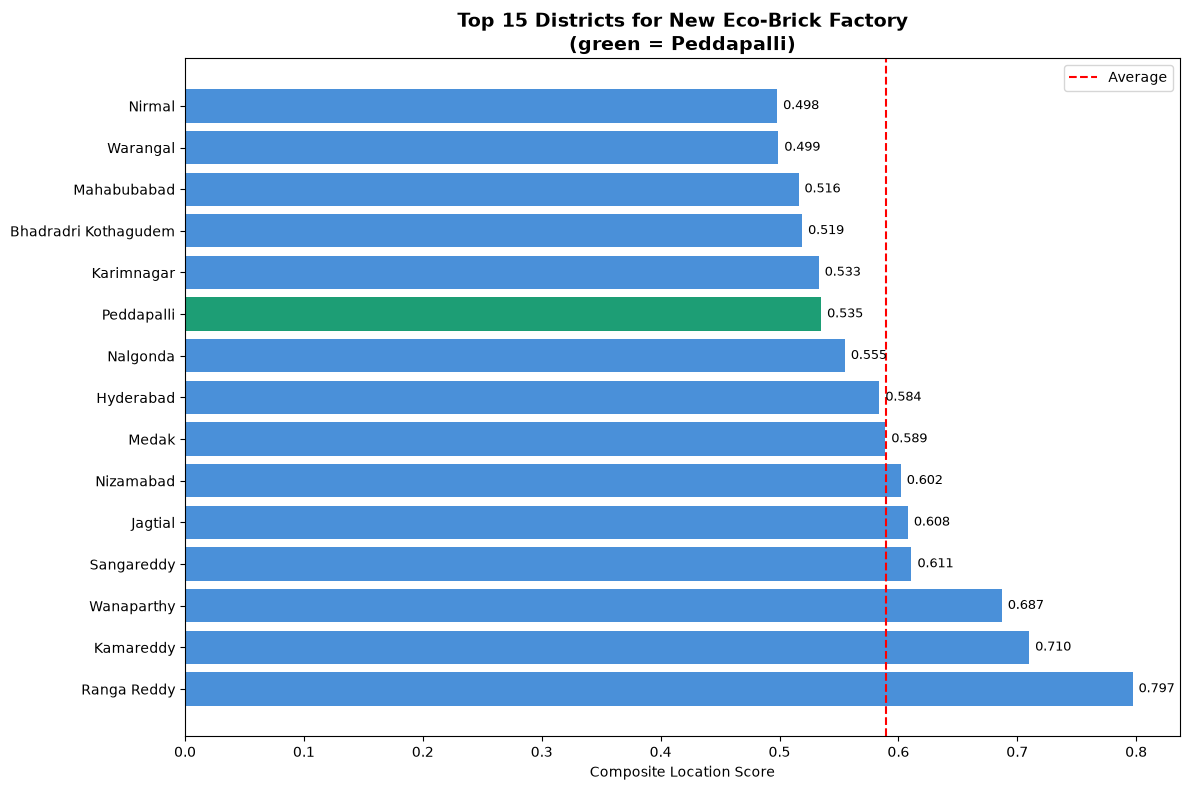

Chart saved ✓


In [6]:
top15 = district.nlargest(15, 'composite_score')

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#1D9E75' if d == 'Peddapalli' else '#4A90D9' 
          for d in top15['Districts']]

bars = ax.barh(top15['Districts'], top15['composite_score'], color=colors)
ax.set_xlabel('Composite Location Score')
ax.set_title('Top 15 Districts for New Eco-Brick Factory\n(green = Peddapalli)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=top15['composite_score'].mean(), 
           color='red', linestyle='--', label='Average')
ax.legend()

# Add score labels
for bar, score in zip(bars, top15['composite_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/location_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

In [7]:
district.to_csv('../data/processed/brick_location_scores.csv', index=False)

top3 = district.nlargest(3, 'composite_score')
print("=== LOCATION RECOMMENDATION ===\n")
for rank, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"#{rank} {row['Districts']}")
    print(f"   Composite score: {row['composite_score']}")
    print(f"   Households: {row['households_2011']:,}")
    print(f"   Eco share: {row['eco_share']}%")
    print(f"   Fully automatic competitors: {row['fully_auto_count']}")
    print(f"   Closure rate: {row['closure_rate']}%")
    print()

=== LOCATION RECOMMENDATION ===

#1 Ranga Reddy
   Composite score: 0.797
   Households: 1,342,187
   Eco share: 83.3%
   Fully automatic competitors: 2
   Closure rate: 0.0%

#2 Kamareddy
   Composite score: 0.71
   Households: 234,109
   Eco share: 0.0%
   Fully automatic competitors: 0
   Closure rate: 0.0%

#3 Wanaparthy
   Composite score: 0.687
   Households: 141,203
   Eco share: 0.0%
   Fully automatic competitors: 0
   Closure rate: 0.0%



## Location Recommendation Summary

**#1 Ranga Reddy** (score 0.797) — largest household base in Telangana (1.3M), 
zero closure rate, already eco-friendly market. Highest demand, stable competition.

**#2 Kamareddy** (score 0.710) — zero fully automatic competitors, zero eco 
adoption (0%) meaning customers are ready to switch, stable market.

**#3 Wanaparthy** (score 0.687) — zero modern competition, zero eco adoption, 
small but stable market.

**Peddapalli (score 0.535)** — ranks 6th overall but is the strongest on raw 
material access (Ramagundam NTPC adjacency). Best choice if supply-chain cost 
optimization is the primary goal over market size.

**Analytical conclusion:** Model is robust — top 2 districts unchanged across 
all 4 weight scenarios. Final recommendation depends on investor priority: 
market size → Ranga Reddy; first-mover in untapped eco market → Kamareddy; 
lowest input costs → Peddapalli.